<a href="https://colab.research.google.com/github/IzhanAli08/LLMResearch/blob/main/Analyze_LLMResults.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
#mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/IzhanResearch/sat_world_and_us_history_predicted.csv')
df.head()

,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer
0,1,world_history,Sumer and Egypt were similar in all of the fol...,agricultural dependence on the silt left behin...,belief in a polytheistic religion centered on ...,enjoyment of protection from invasion by natur...,development of distinct systems of written lan...,engagement in trade with other nearby cultures,C,Question: Sumer and Egypt were similar in all ...,C
1,2,world_history,A follower of the Chinese philosophy of Daoism...,Government intrusiveness should be kept to a m...,Government works best when run by well-educate...,Government should be focused on strengthening ...,Governments that allow too much freedom are do...,Governments have an obligation to suppress ind...,A,Question: A follower of the Chinese philosophy...,A
2,3,world_history,Which of these was NOT a characteristic of ear...,Ability to make and use simple tools,Tendency to live in permanent settlements,Reliance on hunting and gathering techniques,Propensity for creating artistic cave drawings,Mastery of fire for cooking and heating purposes,B,Question: Which of these was NOT a characteris...,B
3,4,world_history,Buddhism was founded in part as a response to ...,Islam,Daoism,Judaism,Hinduism,Christianity,D,Question: Buddhism was founded in part as a re...,D
4,5,world_history,The Kush city of Meroe rose to prominence main...,salt,iron,gold,grain,silver,B,Question: The Kush city of Meroe rose to promi...,A


In [ ]:
# get the first 800 rows
df_final = df.head(801)
df_final.tail()

,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer
796,547,us_history,The U.S. Department of Agriculture was created...,tenant farmers who were forced off their land ...,former slaves who wanted to acquire homesteads...,miners who fought against unsafe working condi...,struggling farmers on the Great Plains,ranchers who wanted to import a healthier bree...,D,Question: The U.S. Department of Agriculture w...,D
797,548,us_history,"The Atlantic Charter, signed by the United Sta...",Aggressor nations would be disarmed after the ...,All nations had the right to choose their own ...,All nations should have equal and free access ...,The United States and Great Britain would not ...,Germany would be split into two nations at the...,E,"Question: The Atlantic Charter, signed by the ...",E
798,549,us_history,I didn't want to believe it at first-people pr...,Korean War,Vietnam War,Persian Gulf War,invasion of Afghanistan,war in Iraq,B,Question: I didn't want to believe it at first...,B
799,550,us_history,All the following are major photojournalists o...,Margaret Bourke-White,Walker Evans,Althea Gibson,Dorothea Lange,Gordon Parks,C,Question: All the following are major photojou...,B
800,551,us_history,The first U.S. school where women and African ...,"Oberlin College, Oberlin, Ohio","Bryn Mawr College, Bryn Mawr, Pennsylvania","Harvard University, Cambridge, Massachusetts","Yale University, New Haven, Connecticut","The University of Pennsylvania, Philadelphia, ...",A,Question: The first U.S. school where women an...,C


In [ ]:
df_us_history = df_final.loc[df['subject'] == 'us_history']
len(df_us_history)

529

In [ ]:
df_world_history = df_final.loc[df['subject'] == 'world_history']
len(df_world_history)

272

In [ ]:
# accuracy of both dataframes predicted answer
correct = len(df_us_history.loc[df_us_history['predicted_answer']==df_us_history['answer']])
print('Accuracy of answers for US history questions=', (correct/len(df_us_history))*100,'percent')




Accuracy of answers for US history questions= 84.12098298676749 percent


In [ ]:
correct1 = len(df_world_history.loc[df_world_history['predicted_answer']==df_world_history['answer']])
print('Accuracy of answers for World history questions=', (correct1/len(df_world_history))*100,'percent')


Accuracy of answers for World history questions= 77.20588235294117 percent


In [ ]:
#find NAns in the dataframe
#which predicted answers are NAns
df_us_history.loc[df_us_history['predicted_answer'].isna()]



,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer


In [ ]:
#confusion matrix, precision, recall f1-score
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
# for US history questions
cm = confusion_matrix(df_us_history['answer'], df_us_history['predicted_answer'])
print('Confusion matrix for US history questions:\n', cm)

Confusion matrix for US history questions:
 [[90  3  5  1  3  4]
 [ 2 98  3  2  5  3]
 [ 2  4 86  2  3  7]
 [ 3  0  1 79  1  9]
 [ 3  2  5  5 92  6]
 [ 0  0  0  0  0  0]]


In [ ]:
print(df_us_history['answer'].unique())
print(df_us_history['predicted_answer'].unique())

['C' 'B' 'D' 'A' 'E']
['B' 'D' 'C' 'A' 'E' 'F']


In [ ]:
# print lines that have predicted M, h and C\n
df_us_history.loc[df_us_history['predicted_answer'].isin(['M', 'h', 'C\n'])]
#update these to C
df_us_history.loc[df_us_history['predicted_answer'].isin(['M', 'h', 'C\n']), 'predicted_answer'] = 'C'

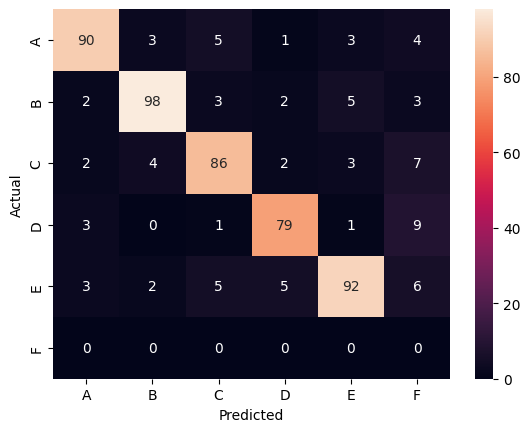

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, fmt='d')
#label preducted and actual as A, B, C ,D, E, F
plt.xticks([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ['A', 'B', 'C', 'D', 'E', 'F'])
plt.yticks([0.5, 1.5, 2.5, 3.5, 4.5, 5.5], ['A', 'B', 'C', 'D', 'E', 'F'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
# print recision, recall, f1
print('Precision for US history questions:', precision_score(df_us_history['answer'], df_us_history['predicted_answer'], average='weighted'))
print('Recall for US history questions:', recall_score(df_us_history['answer'], df_us_history['predicted_answer'], average='weighted', zero_division=False))
print('F1 score for US history questions:', f1_score(df_us_history['answer'], df_us_history['predicted_answer'], average='weighted'))


Precision for US history questions: 0.8900707511570795
Recall for US history questions: 0.8412098298676749
F1 score for US history questions: 0.8649003647350867


In [ ]:
#percentage marked as F
print(len(df_us_history.loc[df_us_history['predicted_answer'] == 'F'])/len(df_us_history))

0.054820415879017016


In [ ]:
print(df_world_history['answer'].unique())
print(df_world_history['predicted_answer'].unique())

['C' 'A' 'B' 'D' 'E' '.']
['C' 'A' 'B' 'D' 'E' 'F']


In [ ]:
#print answers that have A. B. C. D. E. and . values
#df_world_history.loc[df_world_history['answer'].isin(['A.', 'B.', 'C.', 'D.', 'E.','.'])]
#remove dots from answers
df_world_history.loc[df_world_history['answer'].isin(['A.']), 'answer'] = 'A'
df_world_history.loc[df_world_history['answer'].isin(['B.']), 'answer'] = 'B'
df_world_history.loc[df_world_history['answer'].isin(['C.']), 'answer'] = 'C'
df_world_history.loc[df_world_history['answer'].isin(['D.']), 'answer'] = 'D'
df_world_history.loc[df_world_history['answer'].isin(['E.']), 'answer'] = 'E'
df_world_history.loc[df_world_history['answer'].isin(['E.']), 'answer'] = 'E'


In [ ]:
#show lines where predicted answer is A
len(df_world_history.loc[df_world_history['predicted_answer'] == 'A'])

56

In [ ]:
# for US history questions
cm1 = confusion_matrix(df_world_history['answer'], df_world_history['predicted_answer'])
print('Confusion matrix for US history questions:\n', cm1)

Confusion matrix for US history questions:
 [[ 0  0  1  0  0  0  0]
 [ 0 36  3  0  1  1  1]
 [ 0  5 52  2  1  2  5]
 [ 0  7  5 41  0  3  3]
 [ 0  6  2  1 47  3  2]
 [ 0  2  2  2  0 34  2]
 [ 0  0  0  0  0  0  0]]


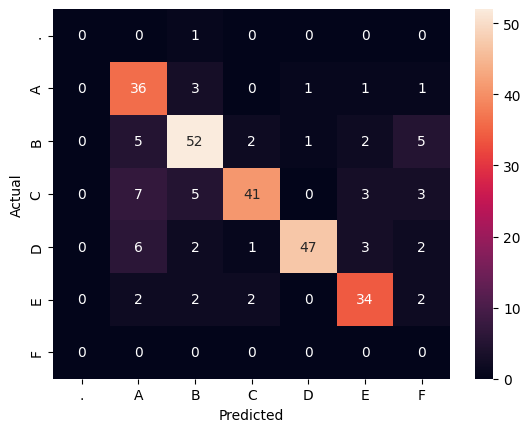

In [ ]:
sns.heatmap(cm1, annot=True, fmt='d')
#label preducted and actual as A, B, C ,D, E, F
plt.xticks([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], ['.','A', 'B', 'C', 'D', 'E', 'F'])
plt.yticks([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5], ['.','A', 'B', 'C', 'D', 'E', 'F'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
#precision, recall, f1
print('Precision for World history questions:', precision_score(df_world_history['answer'], df_world_history['predicted_answer'], average='weighted', zero_division=False))
print('Recall for World history questions:', recall_score(df_world_history['answer'], df_world_history['predicted_answer'], average='weighted', zero_division=False))
print('F1 score for World history questions:', f1_score(df_world_history['answer'], df_world_history['predicted_answer'], average='weighted'))

Precision for World history questions: 0.8268619960623279
Recall for World history questions: 0.7720588235294118
F1 score for World history questions: 0.7920900178253119


In [ ]:
#write us history and world history to csv
df_us_history.to_csv('/content/drive/MyDrive/IzhanResearch/us_history.csv', index=False)
df_world_history.to_csv('/content/drive/MyDrive/IzhanResearch/world_history.csv', index=False)

In [ ]:

#dataframe for US and world history for wrong answers only
df_us_history_wrong = df_us_history.loc[df_us_history['predicted_answer'] != df_us_history['answer']]
df_world_history_wrong = df_world_history.loc[df_world_history['predicted_answer'] != df_world_history['answer']]

In [ ]:
df_us_history_wrong.head()

,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer
272,1,us_history,"The term ""American Indians"" is a misnomer beca...",are not native to the Americas,originally came from Asia,did not inhabit the East Indies,did not speak any European languages,first settled the Americas during the 1400s,C,"Question: The term ""American Indians"" is a mis...",B
279,8,us_history,Which of the following events was most respons...,The founding of Rhode Island,The establishment of Yale College,The banishment of Anne Hutchinson,The founding of Pennsylvania,The Salem witchcraft trials,E,Question: Which of the following events was mo...,A
281,10,us_history,A principal consequence of the Glorious Revolu...,the New England colonists threw Edmund Andros ...,England became a Catholic nation once again,a queen ruled England in her own right for the...,the colonial assemblies began discussing the n...,English Protestants began fleeing to the colon...,A,Question: A principal consequence of the Glori...,C
282,11,us_history,The abolitionist movement had difficulty gaini...,African slaves were content with their status,there were no Africans in powerful positions i...,Africans easily found ways to flout the system...,Northern whites could ignore the wrongs of the...,Quakers were a majority in the colonies and sp...,D,Question: The abolitionist movement had diffic...,F
283,12,us_history,Which of the following people probably had the...,A farmer's wife,A female slave,A male slave,A cobbler,A blacksmith's apprentice,B,Question: Which of the following people probab...,C


In [ ]:
#write the data into csv
df_us_history_wrong.to_csv('/content/drive/MyDrive/IzhanResearch/us_history_wrong.csv', index=False)
df_world_history_wrong.to_csv('/content/drive/MyDrive/IzhanResearch/world_history_wrong.csv', index=False)

In [ ]:
#Calculate cosine similarity between correct response and all wrong answers
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load a pre-trained sentence embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# Get embeddings for actual and predicted answers
actual_answers = df_us_history_wrong["answer"].astype(str).tolist()
predicted_answers = df_us_history_wrong["predicted_answer"].astype(str).tolist()


In [ ]:
actual_embeddings = model.encode(actual_answers, convert_to_tensor=True)
predicted_embeddings = model.encode(predicted_answers, convert_to_tensor=True)

In [ ]:
# Compute cosine similarity
cosine_similarities = cosine_similarity(actual_embeddings.cpu(), predicted_embeddings.cpu())



In [ ]:
# Add similarity scores to the dataframe
df_us_history_wrong["cosine_similarity"] = [cosine_similarities[i, i] for i in range(len(df_us_history_wrong))]


In [ ]:
df_us_history_wrong.head()

,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer,cosine_similarity
272,1,us_history,"The term ""American Indians"" is a misnomer beca...",are not native to the Americas,originally came from Asia,did not inhabit the East Indies,did not speak any European languages,first settled the Americas during the 1400s,C,"Question: The term ""American Indians"" is a mis...",B,0.747561
279,8,us_history,Which of the following events was most respons...,The founding of Rhode Island,The establishment of Yale College,The banishment of Anne Hutchinson,The founding of Pennsylvania,The Salem witchcraft trials,E,Question: Which of the following events was mo...,A,0.566400
281,10,us_history,A principal consequence of the Glorious Revolu...,the New England colonists threw Edmund Andros ...,England became a Catholic nation once again,a queen ruled England in her own right for the...,the colonial assemblies began discussing the n...,English Protestants began fleeing to the colon...,A,Question: A principal consequence of the Glori...,C,0.635481
282,11,us_history,The abolitionist movement had difficulty gaini...,African slaves were content with their status,there were no Africans in powerful positions i...,Africans easily found ways to flout the system...,Northern whites could ignore the wrongs of the...,Quakers were a majority in the colonies and sp...,D,Question: The abolitionist movement had diffic...,F,0.533701
283,12,us_history,Which of the following people probably had the...,A farmer's wife,A female slave,A male slave,A cobbler,A blacksmith's apprentice,B,Question: Which of the following people probab...,C,0.747561


In [ ]:
#calculate average cosine similarity
average_similarity = df_us_history_wrong["cosine_similarity"].mean()
print("Average cosine similarity:", average_similarity)

Average cosine similarity: 0.5925504


In [ ]:
#maximum and minimum cosine simialrity
print("Maximum cosine similarity:", df_us_history_wrong["cosine_similarity"].max())
print("Minimum cosine similarity:", df_us_history_wrong["cosine_similarity"].min())

Maximum cosine similarity: 0.747560977935791
Minimum cosine similarity: 0.4966391921043396


In [ ]:
#Repeat analysis for world history wrong dataset
# Get embeddings for actual and predicted answers
actual_answers = df_world_history_wrong["answer"].astype(str).tolist()
predicted_answers = df_world_history_wrong["predicted_answer"].astype(str).tolist()



In [ ]:
# Compute cosine similarity
cosine_similarities = cosine_similarity(actual_embeddings.cpu(), predicted_embeddings.cpu())

In [ ]:
# Add similarity scores to the dataframe
df_world_history_wrong["cosine_similarity"] = [cosine_similarities[i, i] for i in range(len(df_world_history_wrong))]


In [ ]:
df_world_history_wrong.head()

,id,subject,prompt,A,B,C,D,E,answer,formatted_prompt,predicted_answer,cosine_similarity
4,5,world_history,The Kush city of Meroe rose to prominence main...,salt,iron,gold,grain,silver,B,Question: The Kush city of Meroe rose to promi...,A,0.747561
5,6,world_history,"During the first Punic War, the Romans were MO...",offered an array of natural resources,could serve as a strategic military base,would allow Rome to avenge civilian losses,would increase Rome's ability to trade with th...,could serve as a key location in a Carthaginia...,A,"Question: During the first Punic War, the Roma...",B,0.566400
6,7,world_history,The Battle of Thermopylae was key to Athenian ...,prevented the Persians from reaching and sacki...,wiped out a large portion of the Persian army ...,delayed the Persians' approach and gave the At...,eliminated the Persian navy and forced them to...,weakened Persian morale and left the soldiers ...,C,Question: The Battle of Thermopylae was key to...,A,0.635481
8,9,world_history,Usage of the Silk Roads for trade declined nea...,economic conditions that made long-distance tr...,constant warfare that made roads unsafe for tr...,a decrease in the demand for silk goods in the...,a devastating shortage of Chinese silk,epidemic disease that traveled along the roads...,E,Question: Usage of the Silk Roads for trade de...,A,0.533701
9,10,world_history,"During the Dorian period, Greece experienced f...",period of unusually warm and dry weather condi...,decrease in trade with other Mediterranean cul...,long-term agricultural blight that damaged crops,trend of immigration out of the Greek mainland,war with Persia that used significant resources,D,"Question: During the Dorian period, Greece exp...",A,0.747561


In [ ]:
#average cosine similarity
average_similarity = df_world_history_wrong["cosine_similarity"].mean()
print("Average cosine similarity:", average_similarity)

Average cosine similarity: 0.5833331


In [ ]:
#max and min similarity
print("Maximum cosine similarity:", df_world_history_wrong["cosine_similarity"].max())
print("Minimum cosine similarity:", df_world_history_wrong["cosine_similarity"].min())

Maximum cosine similarity: 0.7475605010986328
Minimum cosine similarity: 0.4966391921043396


In [ ]:
#average similarity for predicted answers that are F
print(df_us_history_wrong.loc[df_us_history_wrong['predicted_answer'] == 'F']['cosine_similarity'].mean())
print(df_world_history_wrong.loc[df_world_history_wrong['predicted_answer'] == 'F']['cosine_similarity'].mean())

0.5468108
0.5868455


In [ ]:
#percentage of answers predicted as F
print(len(df_us_history_wrong.loc[df_us_history_wrong['predicted_answer'] == 'F'])/len(df_us_history_wrong))
print(len(df_world_history_wrong.loc[df_world_history_wrong['predicted_answer'] == 'F'])/len(df_world_history_wrong))

0.34523809523809523
0.20967741935483872
